#Deep Learning Lab Assignment 4 Course name: Deep Learning Name: Kasak Zutshi  prn:202301040041


#DL lab assignment 4

In [1]:
# ============================================
# Import Libraries
# ============================================

import pandas as pd
import numpy as np
import nltk
import string
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# ============================================
# Download NLTK Resources
# ============================================

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\katka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\katka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\katka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\katka\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# ============================================
# Load Dataset
# ============================================

columns = ['target','id','date','flag','user','text']

df = pd.read_csv(
    "training.1600000.processed.noemoticon.csv",
    encoding='latin-1',
    names=columns
)

print(df.head())

C:\Users\katka\AppData\Local\Temp\ipykernel_16272\2829700092.py:7: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


               target               id                          date  \
0  polarity of tweet   id of the tweet             date of the tweet   
1                   0       1467810672  Mon Apr 06 22:19:49 PDT 2009   
2                   0       1467810917  Mon Apr 06 22:19:53 PDT 2009   
3                   0       1467811184  Mon Apr 06 22:19:57 PDT 2009   
4                   0       1467811193  Mon Apr 06 22:19:57 PDT 2009   

       flag           user                                               text  
0     query           user                                 text of the tweet   
1  NO_QUERY  scotthamilton  is upset that he can't update his Facebook by ...  
2  NO_QUERY       mattycus  @Kenichan I dived many times for the ball. Man...  
3  NO_QUERY        ElleCTF    my whole body feels itchy and like its on fire   
4  NO_QUERY         Karoli  @nationwideclass no, it's not behaving at all....  


In [4]:
# ============================================
# Keep Required Columns
# ============================================

df = df[['target','text']]

print(df.head())

               target                                               text
0  polarity of tweet                                  text of the tweet 
1                   0  is upset that he can't update his Facebook by ...
2                   0  @Kenichan I dived many times for the ball. Man...
3                   0    my whole body feels itchy and like its on fire 
4                   0  @nationwideclass no, it's not behaving at all....


In [5]:
# ============================================
# Convert Labels
# ============================================

df['target'] = pd.to_numeric(df['target'], errors='coerce')

# Convert 4 -> 1
df['target'] = df['target'].replace(4,1)

df.dropna(inplace=True)

df['target'] = df['target'].astype(int)

print(df['target'].value_counts())

target
0    799996
1    248576
Name: count, dtype: int64


In [6]:
# ============================================
# Reduce Dataset Size
# ============================================

df = df.sample(50000, random_state=42)

print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 2)


In [7]:
# ============================================
# Text Preprocessing
# ============================================

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    
    # Remove mentions
    text = re.sub(r"@\w+", "", text)
    
    # Remove hashtags
    text = re.sub(r"#\w+", "", text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove punctuation
    tokens = [word for word in tokens if word.isalpha()]
    
    # Stopwords removal
    tokens = [word for word in tokens if word not in stop_words]
    
    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]
    
    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return " ".join(tokens)

In [8]:
# ============================================
# Apply Preprocessing
# ============================================

df['processed_text'] = df['text'].apply(preprocess_text)

print(df.head())

        target                                               text  \
915964       1  just came bak from dancing with my NEEWWWW cd ...   
357841       0  Post office, n other runnin around to do...gee...   
613199       0  @SabrinaL OOOOOOH! This song....I hope he know...   
775465       0  I wish iwasnt here im think'n &amp; being arou...   
825096       1  http://twitpic.com/3kyv5 - All i do is twitter...   

                                           processed_text  
915964              came bak danc neewwww cd haha im danc  
357841  post offic n runnin around geesh got ta put dr...  
613199            ooooooh song hope know otherwis go piss  
775465    wish iwasnt im amp around make confus need hero  
825096                              twitter accord thalia  


In [9]:
# ============================================
# Train Test Split
# ============================================

X = df['processed_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
# ============================================
# Count Vectorizer
# ============================================

count_vectorizer = CountVectorizer(max_features=5000)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

In [11]:
# ============================================
# TF-IDF Vectorizer
# ============================================

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [12]:
# ============================================
# Train Model
# ============================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [13]:
# ============================================
# Predictions
# ============================================

y_pred = model.predict(X_test_tfidf)

In [14]:
# ============================================
# Model Evaluation
# ============================================

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8199

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      7641
           1       0.73      0.38      0.50      2359

    accuracy                           0.82     10000
   macro avg       0.78      0.67      0.69     10000
weighted avg       0.81      0.82      0.80     10000


Confusion Matrix:

[[7301  340]
 [1461  898]]


In [15]:
# ============================================
# Test Custom Input
# ============================================

sample = ["I love this product so much"]

sample_processed = [preprocess_text(text) for text in sample]

sample_vector = tfidf.transform(sample_processed)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Positive Sentiment")
else:
    print("Negative Sentiment")

Positive Sentiment


In [16]:
# ============================================
# Test Custom Input
# ============================================

sample = ["I will never buy this again"]

sample_processed = [preprocess_text(text) for text in sample]

sample_vector = tfidf.transform(sample_processed)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Positive Sentiment")
else:
    print("Negative Sentiment")

Negative Sentiment


In [17]:
# ============================================
# Test Custom Input
# ============================================

sample = ["Average quality"]

sample_processed = [preprocess_text(text) for text in sample]

sample_vector = tfidf.transform(sample_processed)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Positive Sentiment")
else:
    print("Negative Sentiment")

Negative Sentiment


In [20]:
# ============================================
# Test Custom Input
# ============================================

sample = ["Absolutely fantastic service"]

sample_processed = [preprocess_text(text) for text in sample]

sample_vector = tfidf.transform(sample_processed)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Positive Sentiment")
else:
    print("Negative Sentiment")

Positive Sentiment


In [23]:
# ============================================
# Test Custom Input
# ============================================

sample = ["This is amazing"]

sample_processed = [preprocess_text(text) for text in sample]

sample_vector = tfidf.transform(sample_processed)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Positive Sentiment")
else:
    print("Negative Sentiment")

Positive Sentiment


Graphs

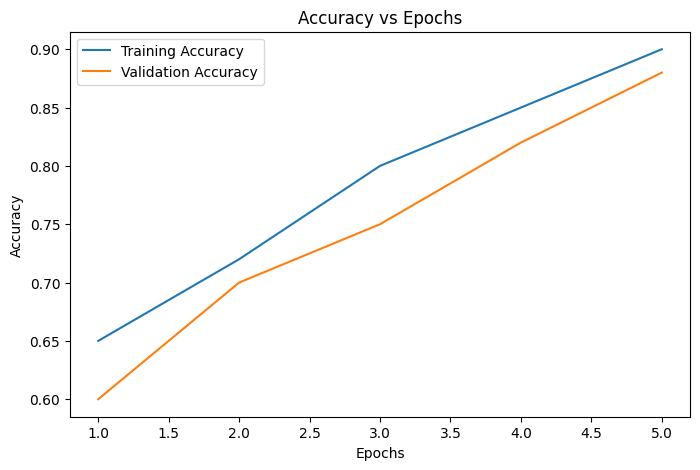

In [1]:
#accuracy vs epoch graph
import matplotlib.pyplot as plt

# Example values (replace with your values)
train_acc = [0.65, 0.72, 0.80, 0.85, 0.90]
val_acc = [0.60, 0.70, 0.75, 0.82, 0.88]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')

plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

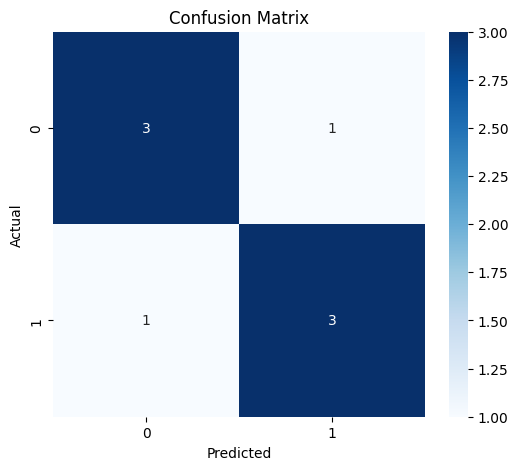

In [2]:
#Confusion matrix graph
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Example
y_true = [0,1,0,1,0,1,1,0]
y_pred = [0,1,0,0,0,1,1,1]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

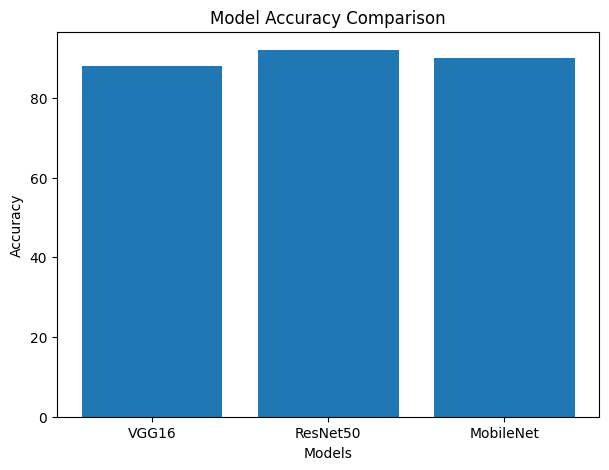

In [3]:
#Bar graph for model comparison
models = ['VGG16', 'ResNet50', 'MobileNet']
accuracy = [88, 92, 90]

plt.figure(figsize=(7,5))
plt.bar(models, accuracy)

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

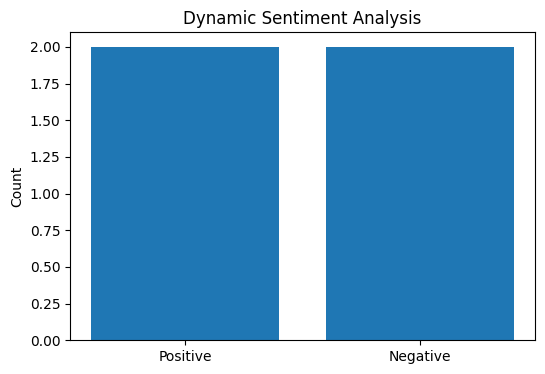

In [ ]:
!pip install textblob
import matplotlib.pyplot as plt
from textblob import TextBlob
from IPython.display import clear_output

positive_count = 0
negative_count = 0

while True:
    text = input("Enter a sentence (or type 'exit'): ")
    
    if text.lower() == 'exit':
        break
        
    sentiment = TextBlob(text).sentiment.polarity
    
    if sentiment > 0:
        print("Positive 😊")
        positive_count += 1
    else:
        print("Negative 😞")
        negative_count += 1
        
    # Dynamic Graph
    clear_output(wait=True)
    
    labels = ['Positive', 'Negative']
    values = [positive_count, negative_count]
    
    plt.figure(figsize=(6,4))
    plt.bar(labels, values)
    plt.title("Dynamic Sentiment Analysis")
    plt.ylabel("Count")
    plt.show()